## Autoencoders and Compression
This is a small experiment to investigate how well/bad Autoencoders compress the dataset images through the feature tensors of its bottleneck. Here we compare to lossless compression with the Python library zlib, which is the main compression algorithm in PNG images. The MNIST standard dataset is used.

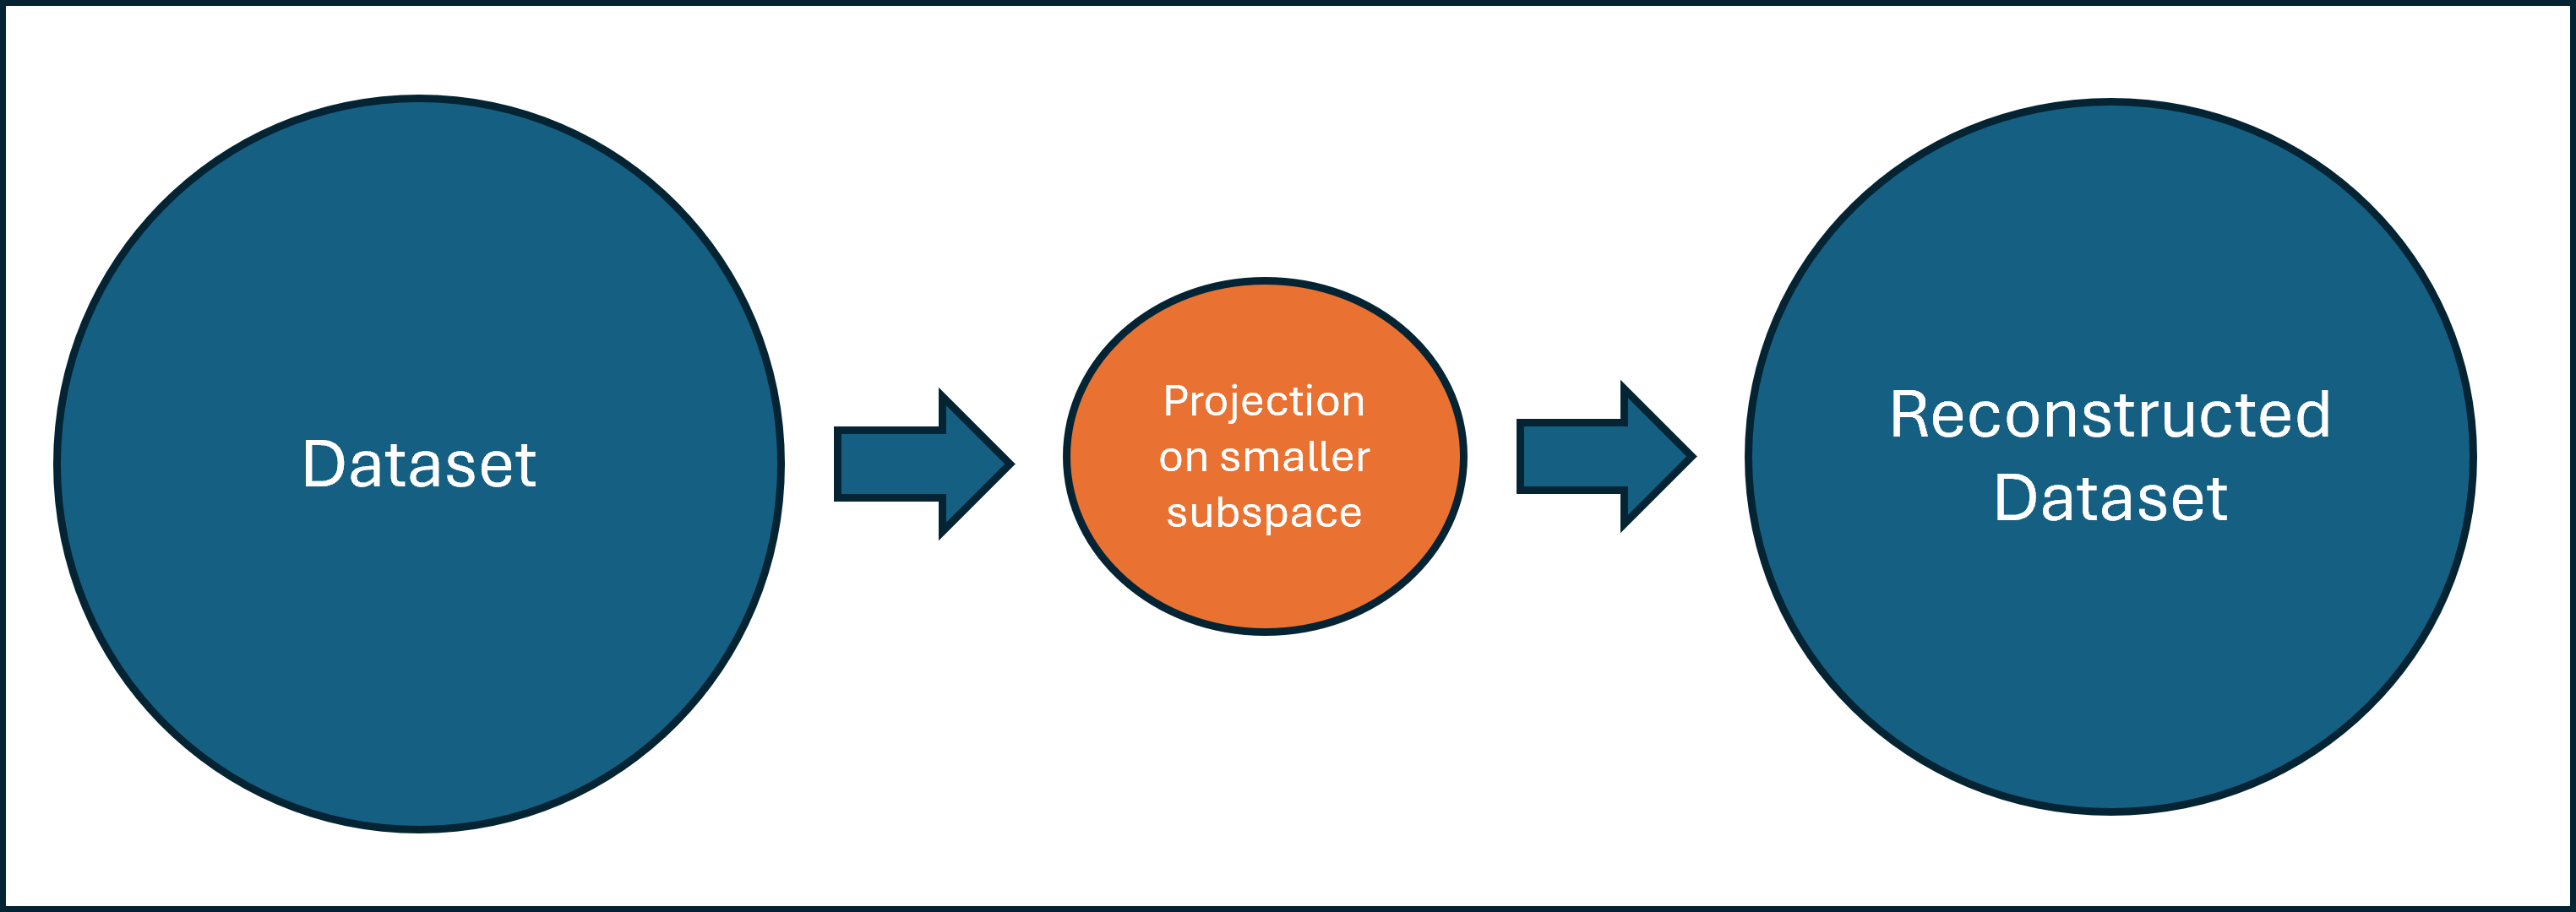

## Implementation Details
To be able to evaluate the compression aspect of Autoencoder models, this project relies on

1. Support to use the module ***tensorflow_datasets*** to be able to easily choose among a reasonable amount of datasets. In the end only ***MNIST*** was used.
2. ***Subclassing*** a keras Model class with custom definion of the encoder/decoder in the init/Constructor of the class
3. Adding ***custom metrics*** to the regular training step of the Model class. This step usually only calculates the model loss for each epoch. Here we can hook us in to calculate any custom metric and define our own additional data. The code for this can be found in lib.py.
4. At the end of every epoch, it is possible for a model user to provide a callback function that calculates custom metrics. These will be part of the history data structure available at the end of training. Such a custom function has been used by ***subclassing*** the ***tf.keras.callback.Callback*** class. The code for this part can be found in lib.py. The reason I had to use this i likely a lack of understanding of ***Eager*** and ***Graph*** execution modes.

## Comparison Metrics

The different compressed dataflow streams compared in this experiment can be visualized with the figure below. Since the general expectation is that autoencoders are not great at compression we compare two information flows that both use the lossless zlib compression:

(a) In this path we use the autoencoder ***latent space*** to represent the training dataset. ***Optionally*** we also define ***sparse error matrices*** that can be used to correct the main errors that the autoencoder itself cannot handle. These objects are then compressed with zlib, since we already know this approach should struggle with compression by itself.

(b) In this path we simply compress all dataset images with the ***lossless zlib algorithm***. This will then represent a reasonable compression baseline that can be compared against. 




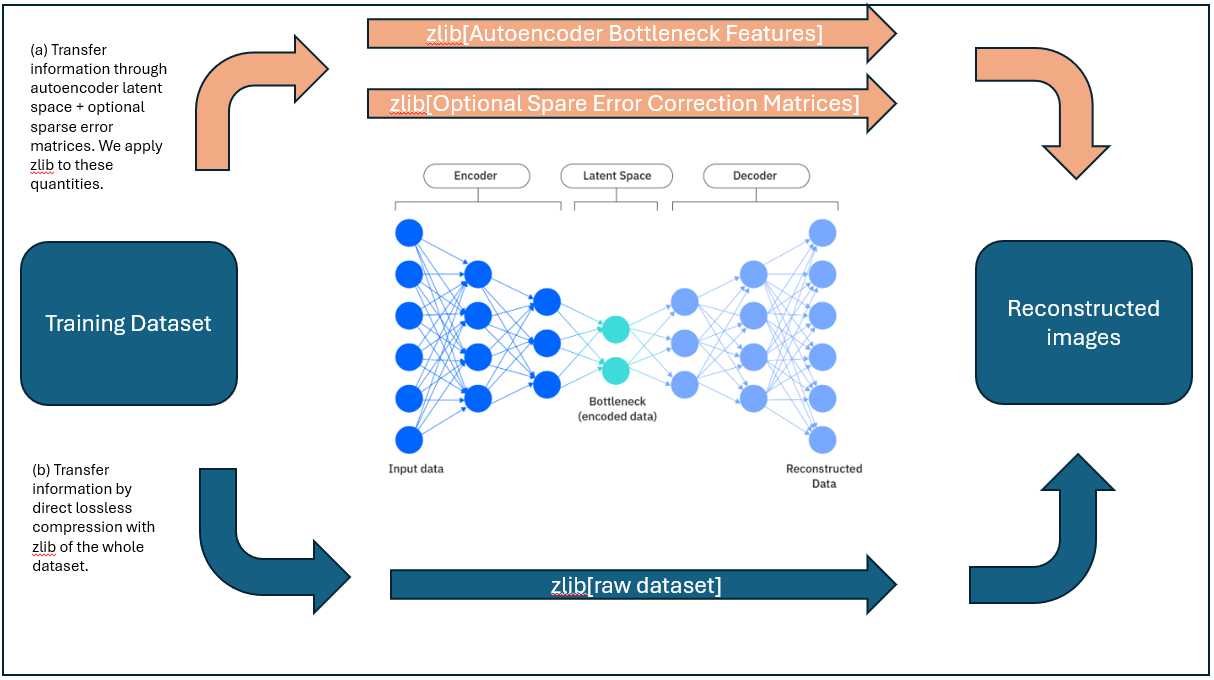

Background image is screenshot from https://www.ibm.com/think/topics/variational-autoencoder

In [10]:
import autoencoder_baseline as ae
import importlib


### Run Autoencoder Model with Dense layers only

In [11]:
importlib.reload(ae)
dataset, model, history = ae.run_model()

Shape (None, 28, 28, 1)
Autoencoder with dense layers


Model: "autoencoder_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 128)            │       797,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,824 (3.04 MB)

 Trainable params: 797,824 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - custom_reconstruction_error: 0.4560 - loss: 0.0232 - val_custom_reconstruction_error: 0.0543 - val_loss: 0.0204 - compression_ratio: 0.3379 - compression_ratio_lossy: 0.1130 - total_original_size: 37641000.0000 - total_feature_size: 6150375.0000 - total_error_correction_size: 37641000.0000 - x_ratio: 0.1284 - x_ratio_noise: 0.6262 - e_ratio: 0.2249 - entropy_noise_stddev: 0.0010 - image_error_threshold: 0.0500
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - custom_reconstruction_error: 0.3322 - loss: 0.0154 - val_custom_reconstruction_error: 0.0444 - val_loss: 0.0149 - compression_ratio: 0.3070 - compression_ratio_lossy: 0.1141 - total_original_size: 37641000.0000 - total_feature_size: 6150375.0000 - total_error_correction_size: 37641000.0000 - x_ratio: 0.1284 - x_ratio_noise: 0.6263 - e_ratio: 0.1929 - entropy_noise_stddev: 0.0010 - image_error_threshold: 0.0500
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - cust

### Training and Compression Metrics

The model training and various compression metrics is presented in the 3-panel figure below. 

Some observations:

- It does not seem worth the effort to enter the overfitting region for better compression. By then the compression metrics have already flattened out. Possibly the situation could be different if training is allowed to progress long enough.
- The mid panel shows that compression ratio of only autoencoder feature tensors are barely beating the full lossless zlib compression (magenta dotted line) of the whole dataset. This is a bit misleading since the dataset is abnormally clean. If we add some invisible noise to the dataset, the lossless compression jumps to the dashed magenta line with a factor of 6. This is a more fair comparison with the red line.
- Adding error matrix corrections to the autoencoder compression still beats the "noisy" full lossless compression of the dataset. This is only true since we made sure these error matrices are sparse in general, filled with mostly zeros, which is compression-friendly.
- The last panel shows that the autoencoder flattens out on a sizeable reconstruction error, where the total sum of prediction errors if about 20% of the absolute sum of the images. This residual is what the error matrices mitigates. 

Available keys in history: dict_keys(['custom_reconstruction_error', 'loss', 'val_custom_reconstruction_error', 'val_loss', 'compression_ratio', 'compression_ratio_lossy', 'total_original_size', 'total_feature_size', 'total_error_correction_size', 'x_ratio', 'x_ratio_noise', 'e_ratio', 'entropy_noise_stddev', 'image_error_threshold'])


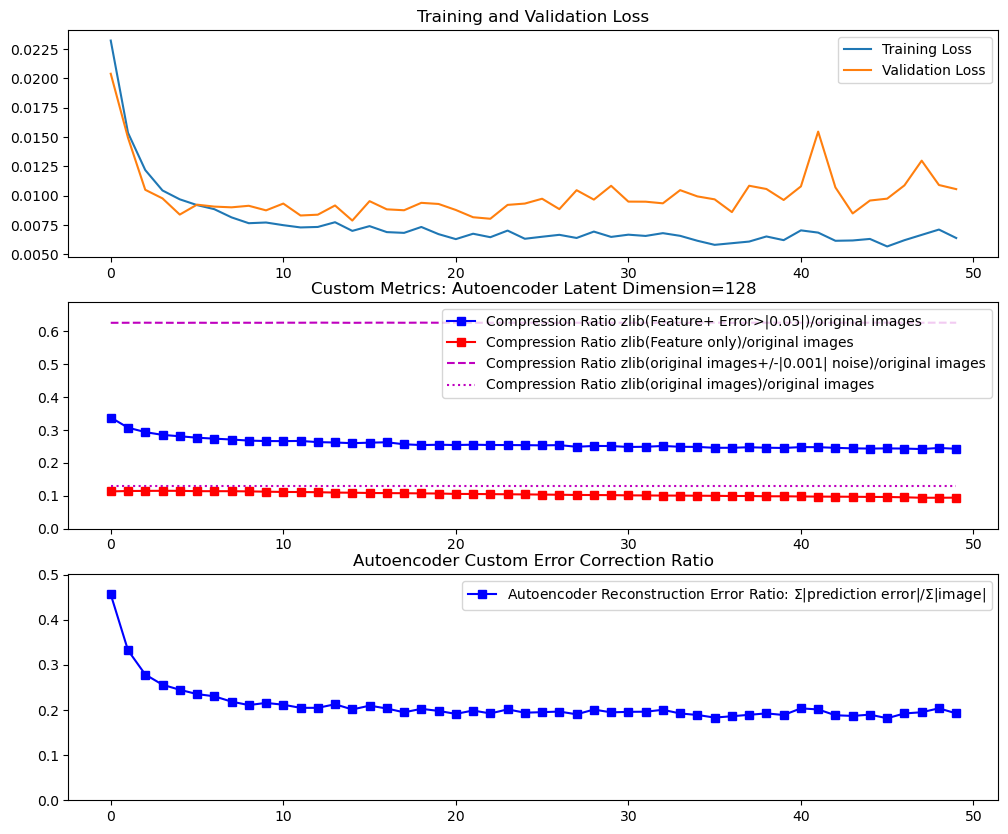

In [12]:
ae.plot(history)

### Example of Autoencoder Reconstruction
The autoencoder manages to reconstruct the images reasonably well as evaluated by the naked eye. There are a fair amount of pixels around the edges with high error values as seen in the last row of the reconstruction examples below. This type or errors should be manageable with the addition of the "sparse error matrix" correction, where we simply set att error values below a threshold to 0, but keep the high values as in the last row. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


2025-12-08 23:02:52.906929: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


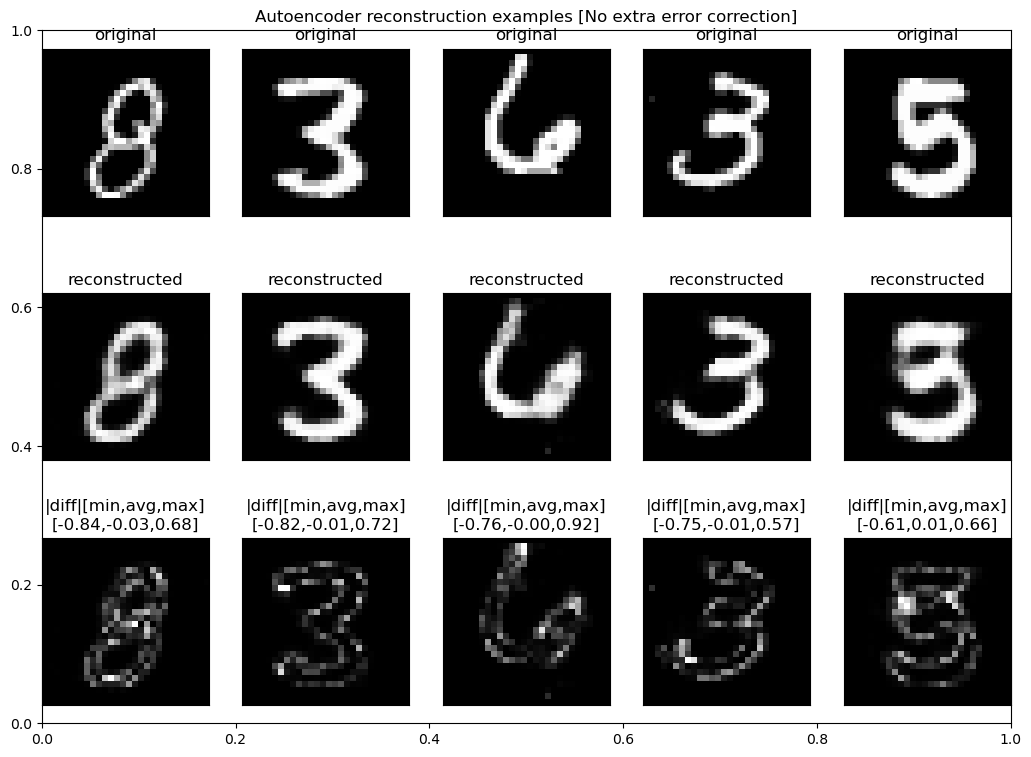

In [13]:
ae.plot_reconstruction_examples(model, dataset['test'], 5)

### Autoencoder with Convolutional Network

There is support for an Autoencoder with a convolutional model in lib.py. It is used by setting the isDense flag to False in the run_model() function of autoencoder_baseline.py. This case is not covered at this point due to time limitations.

## TODO and Limitations

- Size of the Autoencoder models should be taken into account in the compression comparisons. For the simple models used so far, it should not be a big problem though.
- Minimal noise should be added to the dataset, and all training and calculations should be done with this data. Very clean images seem very academic and unrealistic, and give too optimistic lossless compression numbers.
- It should be possible to implement the metrics directly in the Autoencoder class if we decorate custom evaluation functions to run in Tensorflow graph mode. Hopefully the execution speed would improve, it is already slow for a simple dataset like MNIST.
- The results should be double-checked and sanity checked. Especially the reconstruction error ratio which is executed in graph mode.